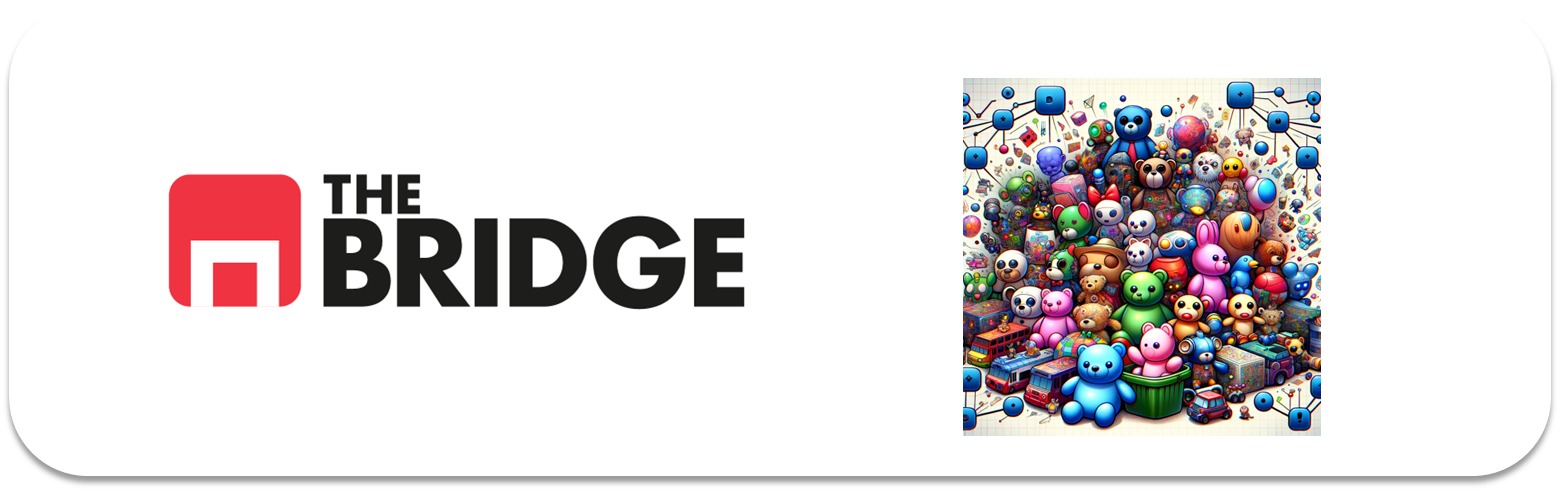

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from itertools import combinations
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

pd.options.mode.copy_on_write = True # CoW por defecto a partir de pandas 3.0.0

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


### 2. Cargar datos, visualizar

In [7]:
drinks = pd.read_csv("./data/empowering_drinks.csv", sep = "|")
drinks

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276
...,...,...,...,...,...
148,0.493343,0.414820,-1.284344,0.009893,0.969783
149,0.332758,-0.389355,-1.344582,0.280575,2.224236
150,0.209232,0.012732,-1.354622,0.296498,1.834923
151,1.395086,1.365208,-1.274305,-0.595160,1.791666


In [8]:
drinks.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [9]:
drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [10]:
drinks.head(10)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276
5,1.716255,0.305159,0.492677,1.729520,0.083015
6,1.308617,0.890014,0.482637,1.745442,-0.003499
7,2.259772,-0.718336,0.954502,0.949319,0.061386
8,1.061565,-0.352802,1.125176,0.949319,0.935177
9,1.358028,-0.243142,1.295850,2.430109,0.299300


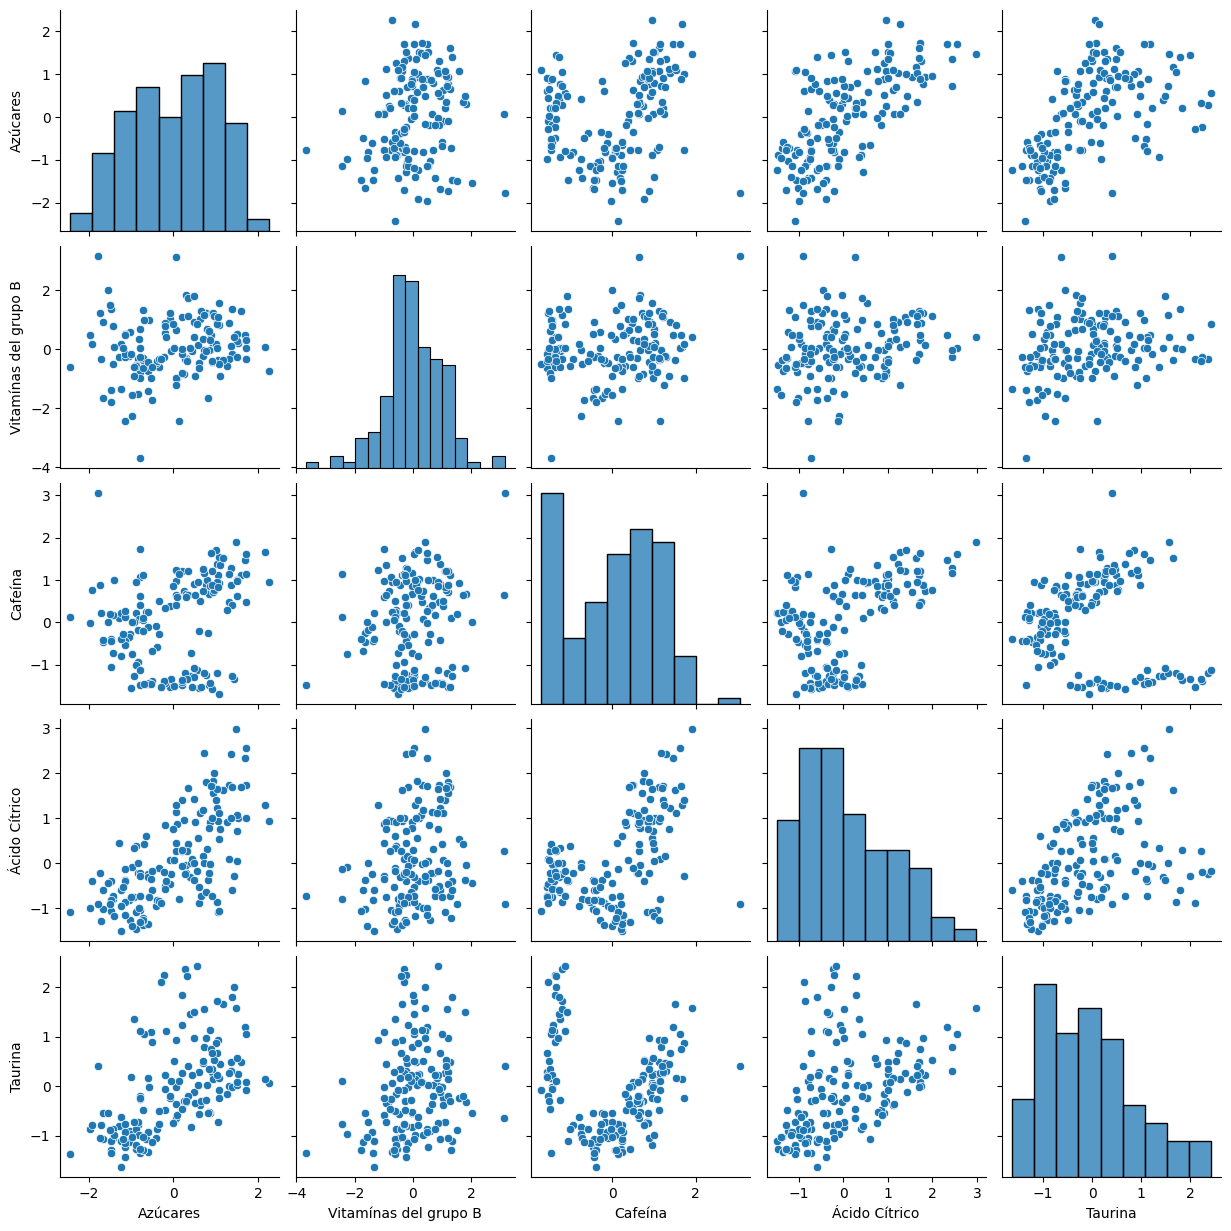

In [11]:
sns.pairplot(drinks)


- 1. `Cafeína y Taurina`: Se ve una relación positiva, cuando sube la cafeína, también tiende a subir la taurina.
- 2. ``Ácido cítrico y Taurina``: También hay una relación positiva, a más ácido cítrico, parece haber más taurina.
- 3. ``Ácido cítrico y Azúcares``: se ve una relacion positiva moderada.
- 4. ``Azúcares y Cafeína``: hy cierta relación, pero parece menos limpia.
- 5. ``Vitaminas del grupo B``: Es la variable que se ve menos relacionada con las demás, sus puntos están más dispersos.


 - Conclusion: La matriz de dispersión muestra que las relaciones parecen darse entre *cafeína*, *ácido cítrico* y *taurina*. Pero , las *vitaminas del grupo B* presentan menos relaciones que con el resto de las variables. Además, algunas gráficas sugieren posibles agrupaciones o relaciones no lineales, especialmente en cafeína y con *Azúcares* y *Cafeína*: hay cierta relación, pero parece menos limpia. Asi que veamoslo en un histograma:

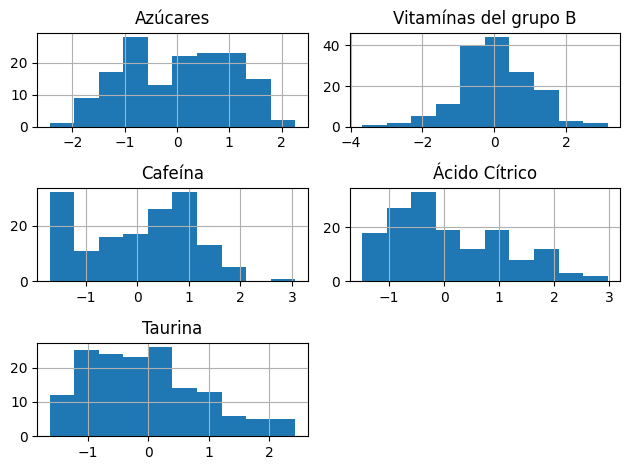

In [12]:
drinks.hist()
plt.tight_layout()

Las variables muestran distribuciones distintas. *Vitaminas del grupo B* tiene una forma más cercana a una distribución normal, pero *Cafeína* y *Ácido Cítrico* tienen mayor asimetría y posible presencia de valores extremos. *Azúcares* y *Taurina* presentan una distribución relativamente equilibrada, aunque no perfectamente normal.

In [13]:
drinks.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


- Las variables ya parecen estandarizadas, ya que sus medias están cerca de 0 y sus desviaciones estándar cerca de 1. Asi que no haria falta 'tocarlas' visto lo anterior.

### 3. Mini EDA/ Seleccion de features

Segun del pairplot, las variables que parecen tener una estructura más útil para segmentación son Cafeína, Taurina y Ácido Cítrico, los pares Cafeína-Taurina y Cafeína-Ácido Cítrico presentan patrones visuales más definidos que podrían facilitar la identificación de grupos, asi ue me los miro para iniciar una feauture selection:

<Axes: xlabel='Cafeína', ylabel='Taurina'>

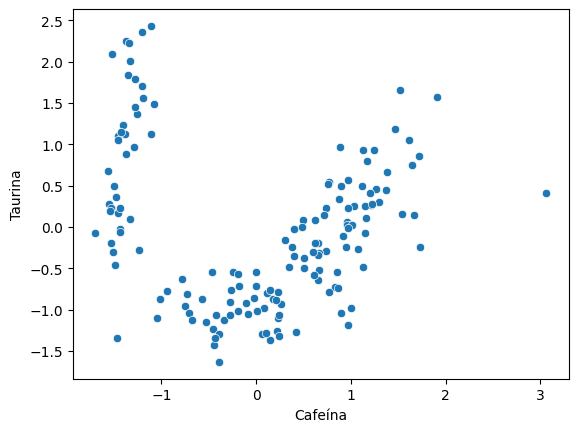

In [14]:
sns.scatterplot(x=drinks['Cafeína'],
                y=drinks['Taurina'])

- Este gráfico apoya bastante la idea de que Cafeína y Taurina son buenas features para segmentar.

<Axes: xlabel='Cafeína', ylabel='Ácido Cítrico'>

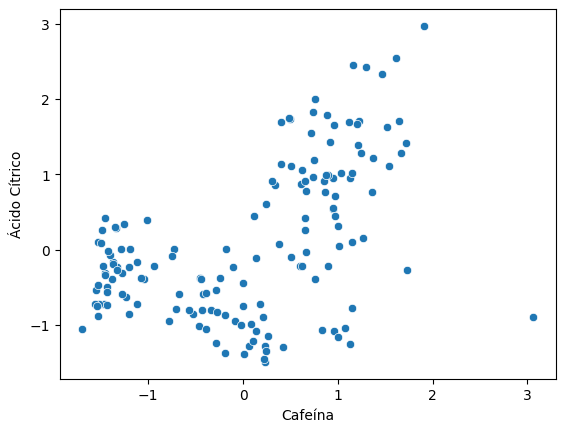

In [15]:
sns.scatterplot(x=drinks['Cafeína'],
                y=drinks['Ácido Cítrico'])

<Axes: xlabel='Azúcares', ylabel='Ácido Cítrico'>

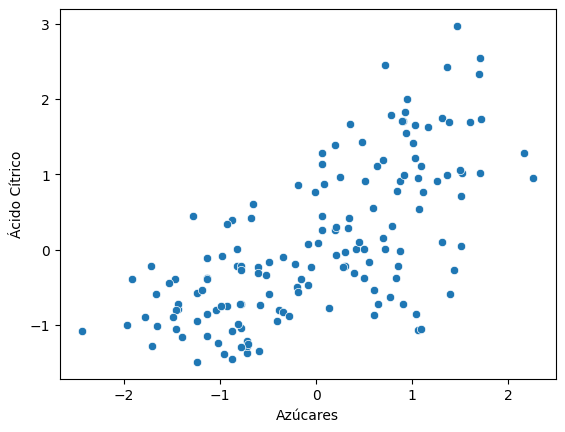

In [16]:
sns.scatterplot(x=drinks['Azúcares'],
                y=drinks['Ácido Cítrico'])

Después de visualizar los pares de variables para identificar cuáles podían aportar mejor entre posibles segmentos. El par ``Cafeína–Ácido Cítrico`` fue el más adecuado, ya que se ven agrupaciones relativamente diferentes y una estructura fácil de interpretar. ``Cafeína–Taurina`` también se visualiza una organización interesante, con varios grupos, aunque con una forma más curva e irregular. Y, ``Azúcares–Ácido Cítrico `` tiene una relación, pero con una distribución más continua y no se si tan útil como combinación principal para segmentar.

In [82]:
features = ["Cafeína", "Taurina"] # las utulizo segun al 1er scaterplott
drinks[features]

,Cafeína,Taurina
0,1.034819,0.251717
1,0.733629,-0.293321
2,1.215533,0.269020
3,1.466525,1.186068
4,0.663351,-0.319276
...,...,...
148,-1.284344,0.969783
149,-1.344582,2.224236
150,-1.354622,1.834923
151,-1.274305,1.791666


5. Selección de modelos, selección de hiperparámetros:

## DBSCAN

In [53]:
from sklearn.cluster import DBSCAN

X = drinks[['Cafeína', 'Taurina']]

dbscan = DBSCAN(eps=0.3, 
                min_samples=4) # para formar un cluster, un punto debe tener al menos 5 puntos cercanos contando su vecindad.
labels = dbscan.fit_predict(X)

labels

array([ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,  0,
        0,  0,  0,  0,  0, -1,  1,  1,  0,  1,  0,  0,  1,  1,  1,  0,  1,
        0,  1,  1,  1,  1,  1,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  1,  1,
        1,  1,  1,  1,  1,  1,  0, -1,  1,  0,  0,  1,  1,  1,  2,  3,  2,
        2,  2,  2,  2,  2,  2,  3,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,
        2,  2,  2,  2,  3,  3,  3,  3,  2,  3,  3,  3,  3,  3,  3,  3,  2])

In [54]:
# Guardamos resultados en labels
drinks['cluster_dbscan'] = labels

In [55]:
drinks['cluster_dbscan'].value_counts().sort_index()

cluster_dbscan
-1     9
 0    61
 1    46
 2    16
 3    21
Name: count, dtype: int64

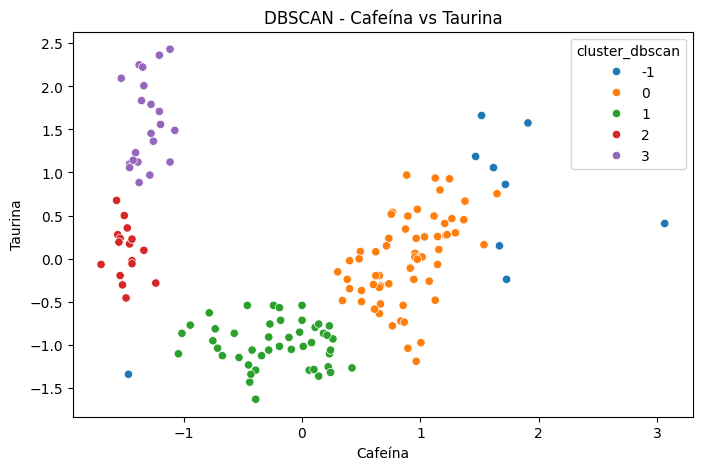

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=drinks,
    x='Cafeína',
    y='Taurina',
    hue='cluster_dbscan',
    palette='tab10'
)
plt.title('DBSCAN - Cafeína vs Taurina')
plt.show()

Jugando un poco con los hiperparametros abajo mencionados, resulta que este es el que entiendo se adapta mejor, ya que los agrupa mejor

Con esta parametrización, DBSCAN detecta 4 clusters bien diferenciados y algunos puntos de ruido, ofreciendo una segmentación mejor y más alineada con el rango esperado.


- DBSCAN(eps=0.3, min_samples=5)
- DBSCAN(eps=0.35, min_samples=5)
- DBSCAN(eps=0.4, min_samples=4)

In [ ]:
# Elegimos eps 'vecindario'

for eps in [0.2, 0.3, 0.4, 0.5, 0.6]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0) # Cuenta cuántos clusters reales hay, sin contar el -1.
    n_noise = list(labels).count(-1) # Cuenta cuántos puntos fueron marcados como ruido.
    print(f"eps={eps} | clusters={n_clusters} | ruido={n_noise}")

eps=0.2 | clusters=6 | ruido=56
eps=0.3 | clusters=4 | ruido=12
eps=0.4 | clusters=2 | ruido=5
eps=0.5 | clusters=2 | ruido=2
eps=0.6 | clusters=1 | ruido=1


- Se probaron varios valores de eps manteniendo fijo ``min_samples=5`` para observar la sensibilidad de DBSCAN. Al aumentar eps, el número de clusters disminuye y el ruido también baja, ya que más puntos pasan a considerarse vecinos. Entre las configuraciones probadas, eps=0.3 tiene una solución razonable al detectar 4 clusters y 12 observaciones de ruido, ajustándose mejor al rango.

In [74]:
X = drinks[['Cafeína', 'Ácido Cítrico']]

dbscan = DBSCAN(eps=0.3, 
                min_samples=5) # para formar un cluster, un punto debe tener al menos 5 puntos cercanos contando su vecindad.
labels_test = dbscan.fit_predict(X)

labels_test

array([ 0,  0,  1, -1,  0,  1,  1,  0,  0, -1,  1,  1,  2, -1,  1,  1,  2,
       -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  1, -1,  0,  1,  0,  0, -1,
        0,  0,  0,  0,  0,  2,  0,  0,  0,  0, -1,  0, -1,  0,  1, -1,  1,
        0,  0,  0,  1, -1,  3,  3,  4,  5,  4,  0,  5, -1,  3,  3,  5,  4,
        0, -1,  4,  4,  4,  4,  0,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  0,  3, -1,  5,  4,  4,  4,  4,  4,  4,  4,  4,  4,  0,  4,  4,
        4,  4,  4,  4,  4,  4,  0, -1,  4,  5,  5,  4,  4,  4,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3])

In [75]:
drinks['cluster_dbscan'] = labels_test

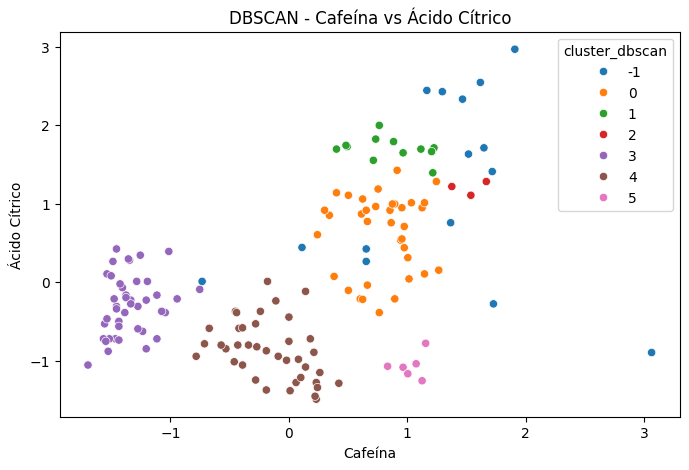

In [76]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=drinks,
    x='Cafeína',
    y='Ácido Cítrico',
    hue='cluster_dbscan',
    palette='tab10'
)
plt.title('DBSCAN - Cafeína vs Ácido Cítrico')
plt.show()

In [73]:
for eps in [0.2, 0.3, 0.4, 0.5, 0.6]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0) # Cuenta cuántos clusters reales hay, sin contar el -1.
    n_noise = list(labels).count(-1) # Cuenta cuántos puntos fueron marcados como ruido.
    print(f"eps={eps} | clusters={n_clusters} | ruido={n_noise}")

eps=0.2 | clusters=5 | ruido=77
eps=0.3 | clusters=6 | ruido=15
eps=0.4 | clusters=2 | ruido=8
eps=0.5 | clusters=1 | ruido=7
eps=0.6 | clusters=2 | ruido=2


In [90]:
train_set_all = drinks.copy()
train_set_all["Cluster"] = dbscan.labels_

In [91]:
train_set_all

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,cluster_dbscan,cluster_kmeans,Cluster
0,1.518613,0.232053,1.034819,1.013009,0.251717,0,2,0
1,0.246290,-0.827996,0.733629,0.965242,-0.293321,0,2,0
2,0.196879,1.109334,1.215533,1.395148,0.269020,1,2,1
3,1.691550,0.487926,1.466525,2.334574,1.186068,-1,2,-1
4,0.295700,1.840403,0.663351,-0.037874,-0.319276,0,2,0
...,...,...,...,...,...,...,...,...
148,0.493343,0.414820,-1.284344,0.009893,0.969783,3,1,3
149,0.332758,-0.389355,-1.344582,0.280575,2.224236,3,1,3
150,0.209232,0.012732,-1.354622,0.296498,1.834923,3,1,3
151,1.395086,1.365208,-1.274305,-0.595160,1.791666,3,1,3


Aqui quise probar con otro par pero no me resulto lo que esperaba, ''jugando'' un poco con el hiperparametro, entiendo que este tipo de clusters no funcionan muy bien ya que vemos en el grafico que hay varios grupos dispersos, siendo que -1 se convina 

``Construimos dendograma jerarquico y utilizo los features ``

In [84]:
drinks[features]

,Cafeína,Taurina
0,1.034819,0.251717
1,0.733629,-0.293321
2,1.215533,0.269020
3,1.466525,1.186068
4,0.663351,-0.319276
...,...,...
148,-1.284344,0.969783
149,-1.344582,2.224236
150,-1.354622,1.834923
151,-1.274305,1.791666


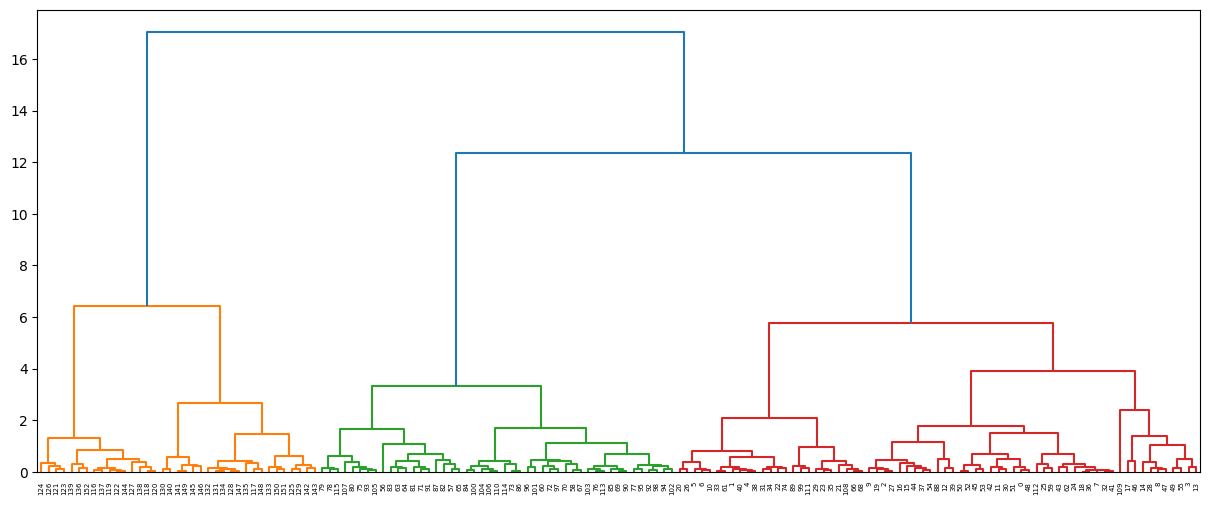

In [83]:
link_method = linkage(drinks[features], method = 'ward')

plt.figure(figsize =(15,6))
dend = dendrogram(link_method)

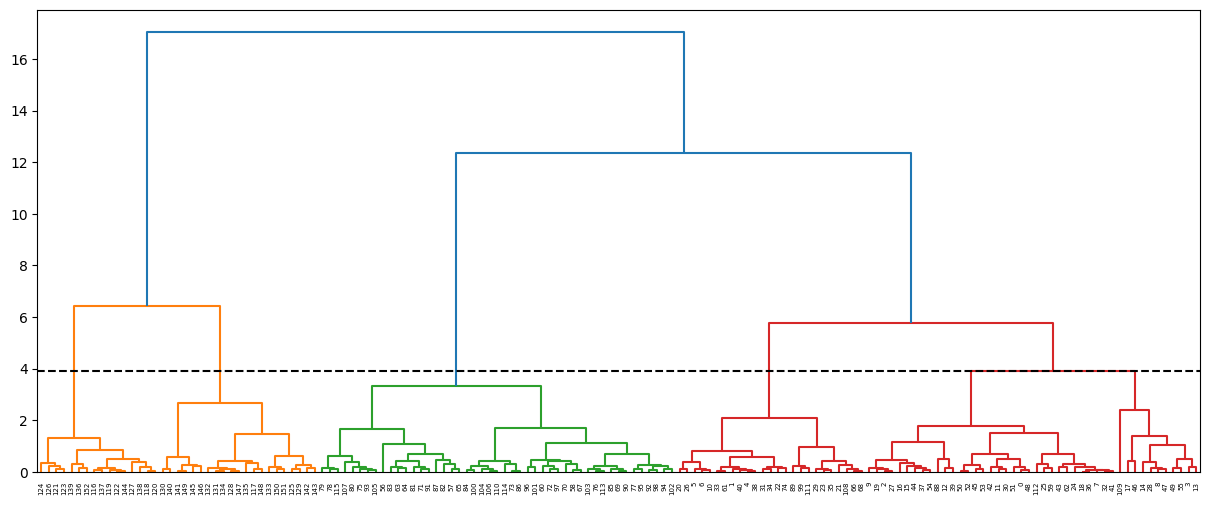

In [85]:
plt.figure(figsize =(15,6))
dend = dendrogram(link_method)
plt.axhline(y = 3.9, color = 'k', linestyle = '--')
plt.show()

In [92]:
clustering_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

clustering_model.fit(drinks[features])

drinks_agg = drinks.copy()
drinks_agg['cluster_dbscan'] = clustering_model.labels_

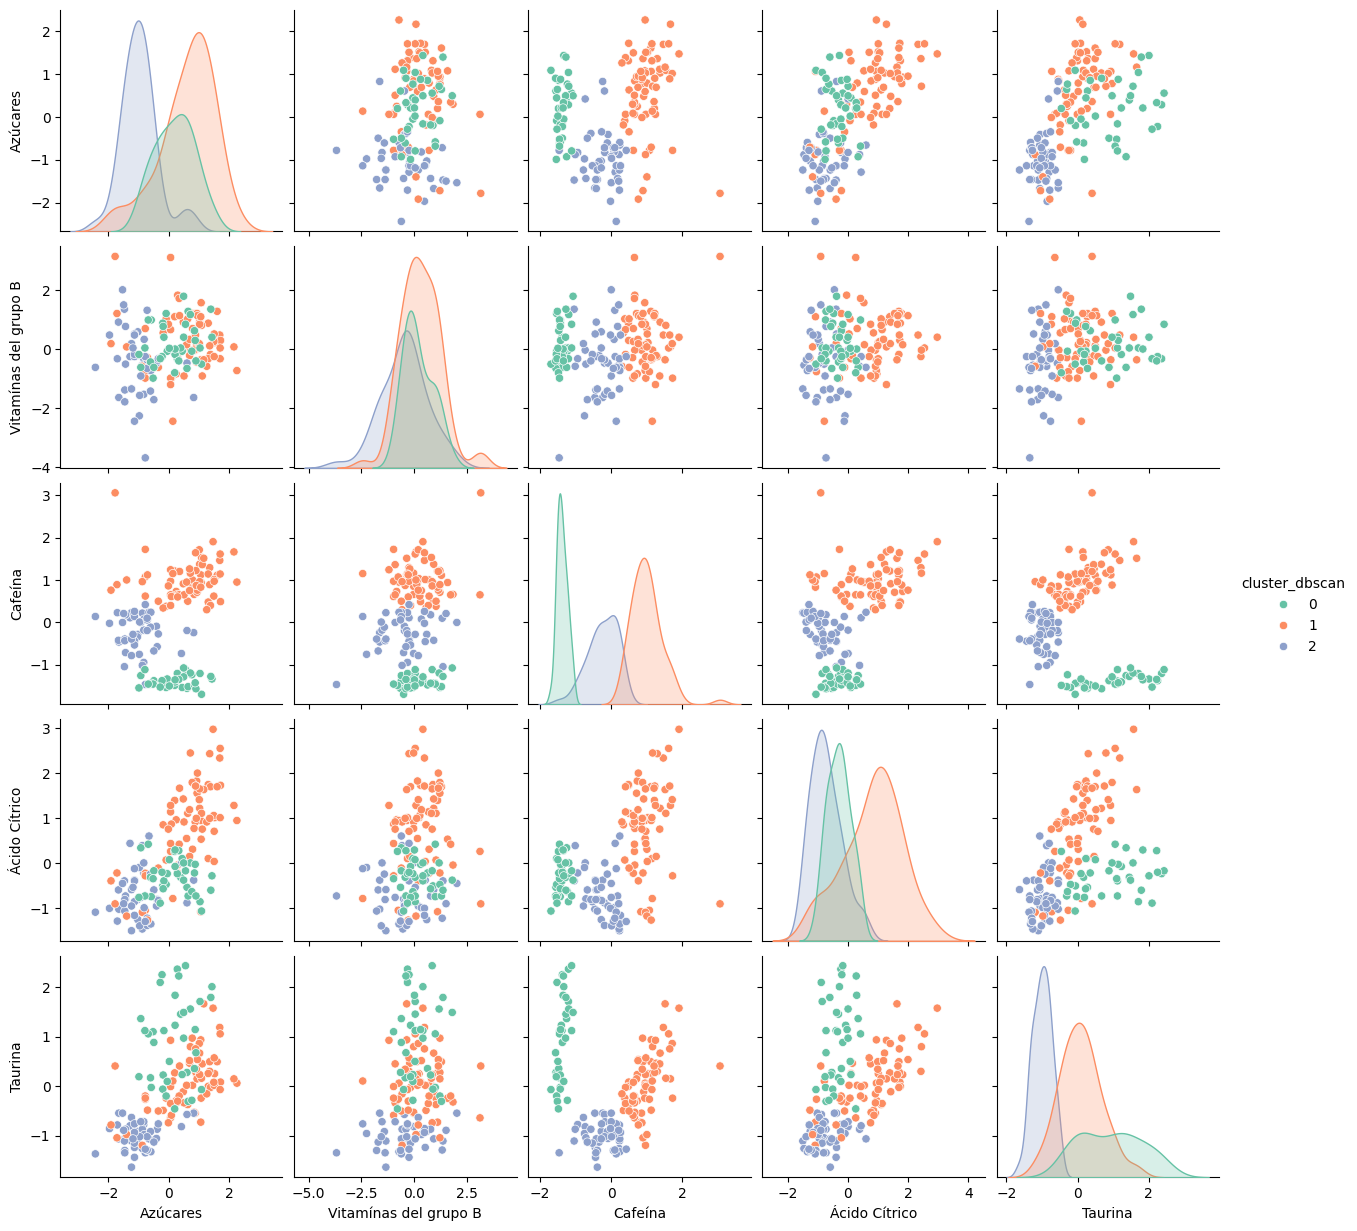

In [97]:
cols = ['Azúcares', 'Vitamínas del grupo B', 'Cafeína', 'Ácido Cítrico', 'Taurina', 'cluster_dbscan']
sns.pairplot(drinks_agg[cols], hue = "cluster_dbscan", palette="Set2")

## K-Means

- Además de DBSCAN, se aplicará K-Means como segundo algoritmo de clustering. Esta elección resulta adecuada porque nos piden  que         deberían existir entre 3 y 5 segmentos, y K-Means permite controlar el número de clusters para comparar distintas       particiones dentro de ese rango.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = drinks[['Cafeína', 'Taurina']]

for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    silhouette = silhouette_score(X, labels)
    print(f"k={k} | silhouette={silhouette:.3f}")

k=3 | silhouette=0.513
k=4 | silhouette=0.496
k=5 | silhouette=0.477


In [ ]:
# Guardamos el resultado del mejor:

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
drinks['cluster_kmeans'] = kmeans.fit_predict(X)

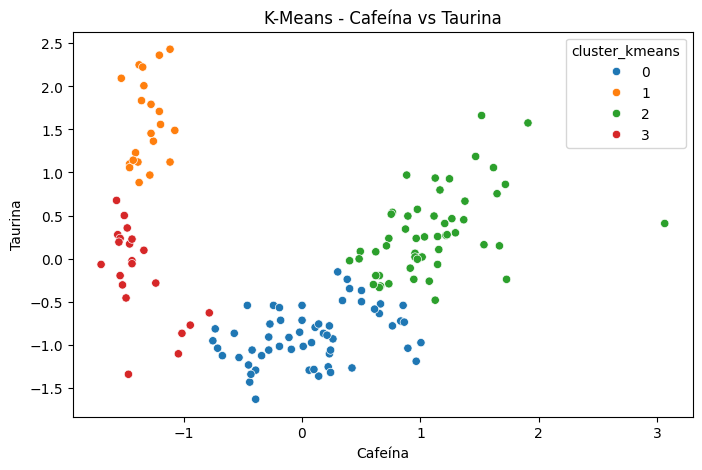

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=drinks,
    x='Cafeína',
    y='Taurina',
    hue='cluster_kmeans',
    palette='tab10'
)
plt.title('K-Means - Cafeína vs Taurina')
plt.show()

Aqui se ve ordenado e interpretable, puede ser una muy buena solución para comparar con DBSCAN

### Comparación rápida con DBSCAN

``K-Means``:

- más limpio

- todos los puntos quedan clasificados


``DBSCAN``:

- detecta ruido

- no necesita fijar el número de clusters

- puede captar mejor densidades y formas irregulares

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

- ``Esta parte me faltara terminar y entiendo que esta incompleta y no podria llegarse a una decision consisa con los resultados asi que hay puntos que me faltan definir y quiero aclararlos en el live :)``

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.